<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Загрузка данных (4 балла)

In [1]:
import gdown
import pandas as pd

#url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
#output = 'file.csv'

#gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

In [2]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [3]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [4]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

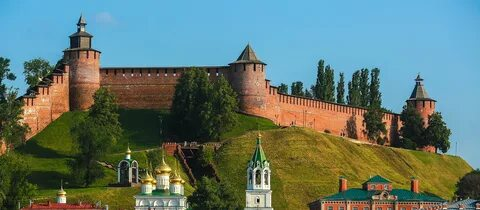

In [5]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [ ]:
# Для начала посмотрим на частоту встречаемости слов и удалим строки с слишком редко встречаемыми словами 

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['en_txt'])
word_counts = X.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()

word_freq_df = pd.DataFrame({
    'word': words,
    'count': word_counts
}).sort_values(by='count', ascending=False)
word_freq_df['count'].value_counts().head(10)

count
1     636
2     255
3     122
4     103
5      61
6      59
7      54
10     30
9      26
11     25
Name: count, dtype: int64

In [7]:
rare_words = set([words[i] for i, count in enumerate(word_counts) if count <= 4])

len(rare_words)

1116

In [8]:
def contains_rare_word(text):
    return any(word in rare_words for word in text.split())

In [10]:
data['has_rare'] = data['en_txt'].apply(contains_rare_word)
data['has_rare'].value_counts()

has_rare
False    13185
True      1449
Name: count, dtype: int64

In [11]:
data_clean = data.loc[data['has_rare'] == False].reset_index(drop=True)

In [ ]:
# Уже на моменте с построением раги заметил тексты, семантически идентичные друг другу
# Тоже избавимся от них 

In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

texts = data_clean['en_txt'].dropna().unique()

embeddings = model.encode(texts)

similarity_matrix = cosine_similarity(embeddings)

semantic_duplicates = []
threshold = 0.90

for i in range(len(texts)):
    for j in range(i + 1, len(texts)):
        if similarity_matrix[i][j] > threshold:
            semantic_duplicates.append({
                'text1': texts[i],
                'text2': texts[j],
                'similarity': similarity_matrix[i][j],
                'index1': i,
                'index2': j
            })


if semantic_duplicates:
    semantic_duplicates.sort(key=lambda x: x['similarity'], reverse=True)
    
    for i, dup in enumerate(semantic_duplicates[:10]):
        print(f"\n{i+1}. Сходство: {dup['similarity']:.4f}")
        print(f"   Текст 1: {dup['text1'][:100]}...")
        print(f"   Текст 2: {dup['text2'][:100]}...")


1. Сходство: 0.9994
   Текст 1: aerial view of a city with a river and a bridge...
   Текст 2: aerial view of a city with a bridge and a river...

2. Сходство: 0.9993
   Текст 1: arafed building with a green roof and a green dome...
   Текст 2: arafed building with a green dome and a green roof...

3. Сходство: 0.9992
   Текст 1: arafed church with a green roof and a green dome...
   Текст 2: arafed church with a green dome and a green roof...

4. Сходство: 0.9992
   Текст 1: an old photo of a building with a clock tower on top...
   Текст 2: an old photo of a building with a clock tower on the top...

5. Сходство: 0.9992
   Текст 1: arafed view of a city with a river and a bridge...
   Текст 2: arafed view of a city with a bridge and a river...

6. Сходство: 0.9992
   Текст 1: an old photo of a building with a fence and a gate...
   Текст 2: an old photo of a building with a gate and a fence...

7. Сходство: 0.9991
   Текст 1: snowy scene of a church with a golden dome and a steeple.

In [14]:
texts = data_clean['en_txt'].dropna().tolist()
embeddings = model.encode(texts)

similarity_matrix = cosine_similarity(embeddings)
threshold = 0.90

indices_to_remove = set()

for i in range(len(texts)):
    if i not in indices_to_remove:  
        for j in range(i + 1, len(texts)):
            if similarity_matrix[i][j] > threshold:
                indices_to_remove.add(j)  


text_to_index_map = {}
for idx, row in data_clean.dropna(subset=['en_txt']).iterrows():
    text_to_index_map[row['en_txt']] = idx

df_indices_to_remove = []
for i in indices_to_remove:
    if i < len(texts):
        text = texts[i]
        if text in text_to_index_map:
            df_indices_to_remove.append(text_to_index_map[text])

data_clean = data_clean.drop(df_indices_to_remove)



In [ ]:
# Текстов для некоторых объектов всё ещё слишком много, так что оставим по 10 самых больших записей 

In [15]:
data_clean['Name'].value_counts()

Name
Владимир                                  60
Кресень                                   54
Театр кукол                               54
Преображенская церковь на Уктусе          46
Церковь во имя Всемилостивейшего Спаса    45
                                          ..
церковь Михаила Архангела                  5
Мемориальный дом-музей М. Богдановича      5
Сретенский храм                            5
Ярославский музей-заповедник               4
Каменный мост                              3
Name: count, Length: 386, dtype: int64

In [16]:
data_clean['City'].value_counts()

City
Екатеринбург       2138
Ярославль          2067
Нижний Новгород    2009
Владимир           2005
Name: count, dtype: int64

In [18]:
def calc_word_counts(text):
    return len(text.split())

data_clean['word_counts'] = data_clean['en_txt'].apply(calc_word_counts)


In [19]:
top_10_per_name = data_clean.sort_values('word_counts', ascending=False).groupby('Name').head(10).reset_index(drop=True)

In [20]:
top_10_per_name['Name'].value_counts()

Name
Кресень                                  10
Николая Чудотворца                       10
Ярославское художественное училище       10
Ярославская соборная мечеть              10
Школа № 33 имени Карла Маркса            10
                                         ..
Мемориальный дом-музей М. Богдановича     5
Сретенский храм                           5
церковь Михаила Архангела                 5
Ярославский музей-заповедник              4
Каменный мост                             3
Name: count, Length: 386, dtype: int64

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [21]:
# А вот и собственно рага
# Будем задавать раге определённые вопросы, а на выходе получать ответы на русском и английском по всем текстам объектов из топ-3 релевантных чанков (+ названия и картинки)
# Для получения эмбедингов и ragatouille ранжирования будем использовать легенькие модели
# А вот для ответов будем использовать qwen2.5 на 1.5ККК параметров
# Вы спросите меня, а почему именно qwen2.5... Ранее я просто использовал её для одного из проектов и уже скачал её на компьютер)))


In [ ]:
# Кстати, ниже прикрепил картинку ответа одной из первых версий раги
# Моделька не сразу захотела работать на русском...
#
# Партия выдать миска риса и кошко-жена )
#
# P.s.
# Периодически иероглифы всё ещё могут встретится, тут уже надо бы подумывать про историю с подробным систем промптом
# или же валидировать ответ по символам и простить модель передумывать ответ 
# Но это уже совсем другая история...

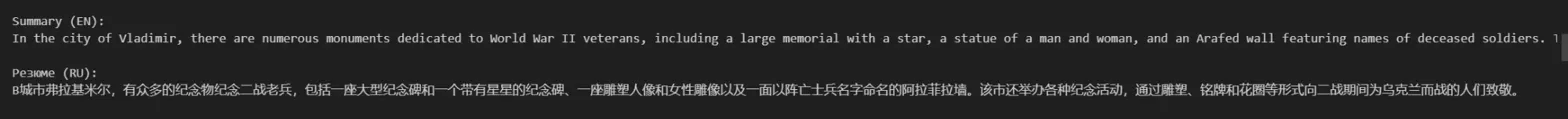

In [25]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from ragatouille import RAGPretrainedModel
import faiss
from PIL import Image
from io import BytesIO
import base64
from typing import List, Dict

class ArchitecturalRAG:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.embedding_model = SentenceTransformer(model_name)
        self.reranker = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")
        self.index = None
        self.data = None
        
    def build_index(self, df: pd.DataFrame, text_column='en_txt'):
        self.data = df.copy()
        texts = df[text_column].fillna('').tolist()
        embeddings = self.embedding_model.encode(texts, show_progress_bar=True)
        self.index = faiss.IndexFlatL2(embeddings.shape[1])
        self.index.add(embeddings.astype('float32'))
        
    def search(self, query: str, top_k=3, initial_k=20) -> List[Dict]:
        query_embedding = self.embedding_model.encode([query])
        distances, indices = self.index.search(query_embedding.astype('float32'), initial_k)
        
        candidates = [{'idx': idx, **self.data.iloc[idx][['Name', 'City', 'en_txt', 'image']].to_dict()} 
                     for idx in indices[0]]
        
        texts = [c['en_txt'] for c in candidates]
        reranked = self.reranker.rerank(query=query, documents=texts, k=len(texts))
        text_to_score = {r['content']: r['score'] for r in reranked}
        
        for c in candidates:
            c['score'] = text_to_score.get(c['en_txt'], -999)
        
        candidates.sort(key=lambda x: x['score'], reverse=True)

        seen, results = set(), []
        for c in candidates:
            if c['Name'] not in seen:
                seen.add(c['Name'])
                results.append(c)
                if len(results) >= top_k:
                    break
        return results
    
    def get_image(self, image_data: str) -> Image.Image:
        return Image.open(BytesIO(base64.b64decode(image_data))).convert('RGB')
    
    def _load_local_model(self):
        if not hasattr(self, 'llm'):
            from transformers import AutoTokenizer, AutoModelForCausalLM
            import torch
            
            model_path = "qwen2.5-1.5b-instruct-local"
            self.tokenizer = AutoTokenizer.from_pretrained(model_path)
            self.llm = AutoModelForCausalLM.from_pretrained(
                model_path,
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                device_map="auto"
            )
    
    def _generate_summary(self, name: str, city: str, all_texts: List[str]) -> Dict[str, str]:
        self._load_local_model()
        
        combined = '\n\n'.join(all_texts)
        
        prompt = f"""Based on the following descriptions, provide a brief 2-3 sentence summary about this monument.

Monument: {name}
City: {city}

Descriptions:
{combined}

Provide two versions:
1. ENGLISH: [write summary in English here]
2. RUSSIAN: [write summary in Russian here]"""
        
        messages = [{"role": "user", "content": prompt}]
        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer([text], return_tensors="pt").to(self.llm.device)
        
        outputs = self.llm.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.7,
            do_sample=True,
            top_p=0.9
        )
        
        response = self.tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True).strip()
        
        return {'response': response}
    
    def query(self, query: str, top_k=3, initial_k=20):
        print(f"\nQuery: {query}\n")
        results = self.search(query, top_k, initial_k)
        
        for i, r in enumerate(results, 1):
            all_texts = self.data[self.data['Name'] == r['Name']]['en_txt'].fillna('').tolist()
            
            summary = self._generate_summary(r['Name'], r['City'], all_texts)
            
            print(f"{'='*60}")
            print(f"Result #{i}")
            print(f"Name: {r['Name']}")
            print(f"City: {r['City']}")
            print(f"Score: {r['score']:.4f}\n")
            print(f"Summary:\n{summary['response']}\n")

            try:
                img = self.get_image(r['image'])
                display(img)
                print(f"↑ {r['Name']}, {r['City']}\n")
            except Exception as e:
                print(f"Error loading image: {e}\n")



Batches:   0%|          | 0/458 [00:00<?, ?it/s]


Query: Tell us about the monuments of the Second World War

WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 111.11it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Result #1
Name: Погибшим в ВОВ
City: Владимир
Score: 22.6875

Summary:
### English Summary:

The monument in Vladimir features various memorials dedicated to World War II veterans. There is a central monument with a map of Ukraine, a memorial with a large stone featuring a picture of a man and a woman, and numerous other statues, sculptures, and monuments throughout the park. The city also has several memorials honoring those who lost their lives during the war.

### Russian Summary:

Монумент в Волыни представлен множеством памятников посвященных Второй мировой войне. Центральный монумент содержит карту Украины, а также различные памятники с мраморными плитами и статуями, среди которых множество других творений. Кроме того, в городе есть несколько памятников, посвященных жертвам военных действий.



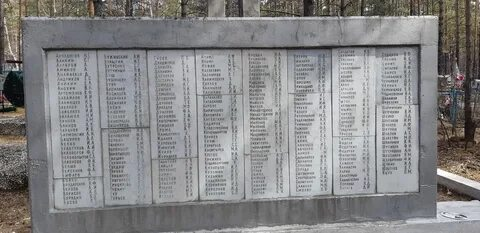

↑ Погибшим в ВОВ, Владимир

Result #2
Name: Вечный огонь (Ярославль)
City: Ярославль
Score: 13.9375

Summary:
### Summary (ENGLISH):
This monument features various elements including a central fire, statues, wreaths, and other architectural details like a church or a building, creating a picturesque scene in the city of Yaroslavl.

### Summary (RUSSIAN):
Этот монумент включает различные элементы, такие как центральный огонь, статуи, памятники и другие архитектурные детали, такие как кирпичную церковь или здание, создавая нарядное место в городе Ярославль.



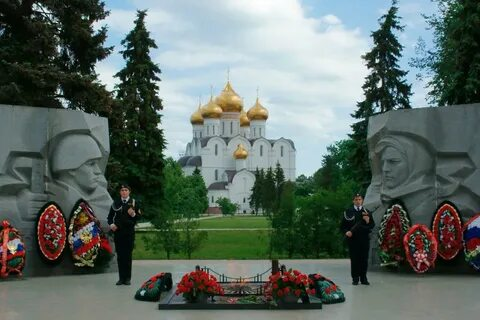

↑ Вечный огонь (Ярославль), Ярославль

Result #3
Name: Воинское мемориальное кладбище
City: Ярославль
Score: 13.9141

Summary:
**ENGLISH:** The Voivodskoye Morskoye Mementokladbishchche (War Cemetery) in Yaroslavl features several distinctive elements such as gray granite blocks scattered across the grounds, benches positioned amidst a snowy park, and an aerial view showcasing a park with arched structures, fountains, and a skyline.
  
**RUSSIAN:** Войковское мемориальное кладбище в Ярославле состоит из множества черных гранита блоков на земле, скамеек рядом с полями с снегом и арочными конструкциями в центре парка. Аэрофотография показывает парк с гранитной дорогой, красными арками и горизонтом с небом.



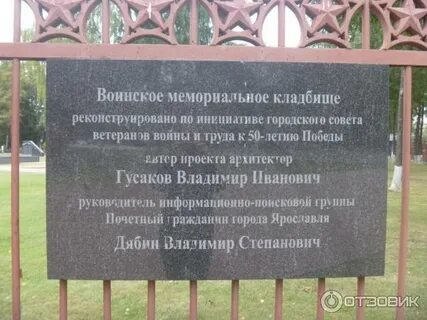

↑ Воинское мемориальное кладбище, Ярославль



In [50]:
rag = ArchitecturalRAG()
rag.build_index(data, text_column='en_txt')
rag.query("Tell us about the monuments of the Second World War", top_k=3)

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP

def visualize_embeddings(embeddings, labels=None, figsize=(14, 5)):

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings)
    
    umap = UMAP(n_components=2, n_neighbors=15, random_state=42)
    umap_result = umap.fit_transform(embeddings)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    scatter1 = axes[0].scatter(pca_result[:, 0], pca_result[:, 1], 
                               c=labels, cmap='tab10', alpha=0.6, s=50)
    axes[0].set_title(f'PCA (var: {pca.explained_variance_ratio_.sum():.2%})')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    axes[0].grid(True, alpha=0.3)

    scatter2 = axes[1].scatter(umap_result[:, 0], umap_result[:, 1], 
                               c=labels, cmap='tab10', alpha=0.6, s=50)
    axes[1].set_title('UMAP')
    axes[1].set_xlabel('UMAP1')
    axes[1].set_ylabel('UMAP2')
    axes[1].grid(True, alpha=0.3)
    
    if labels is not None:
        plt.colorbar(scatter2, ax=axes[1])
    
    plt.tight_layout()
    return fig


def visualize_rag_embeddings(rag, data, group_by='City'):
    embeddings = np.array([rag.index.reconstruct(i) for i in range(rag.index.ntotal)])
    labels = pd.factorize(data[group_by])[0] if group_by else None
    
    return visualize_embeddings(embeddings, labels)




c:\Users\Denis\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


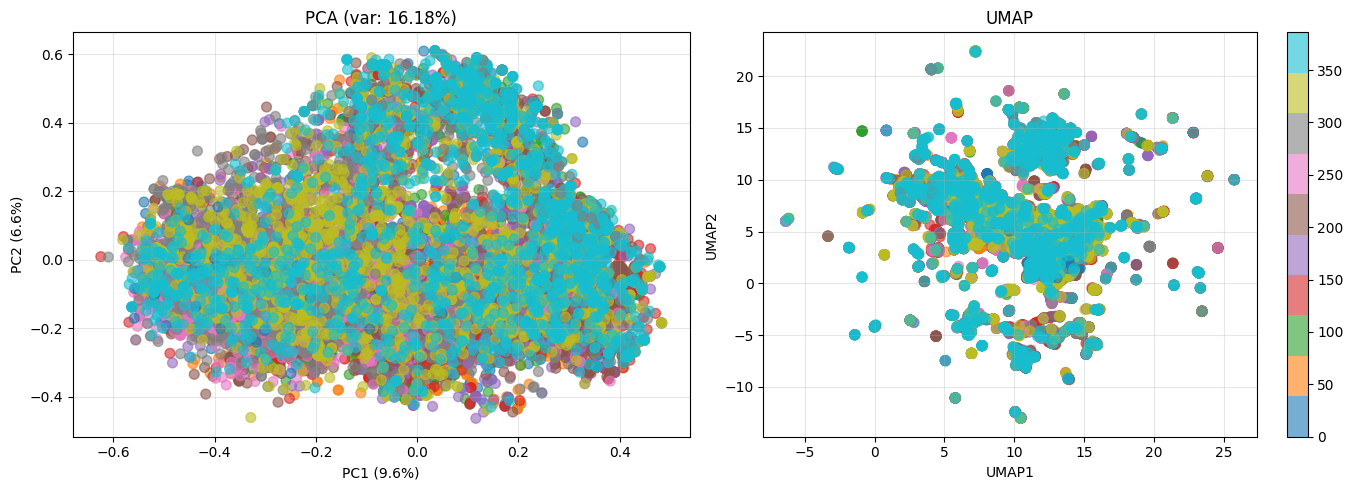

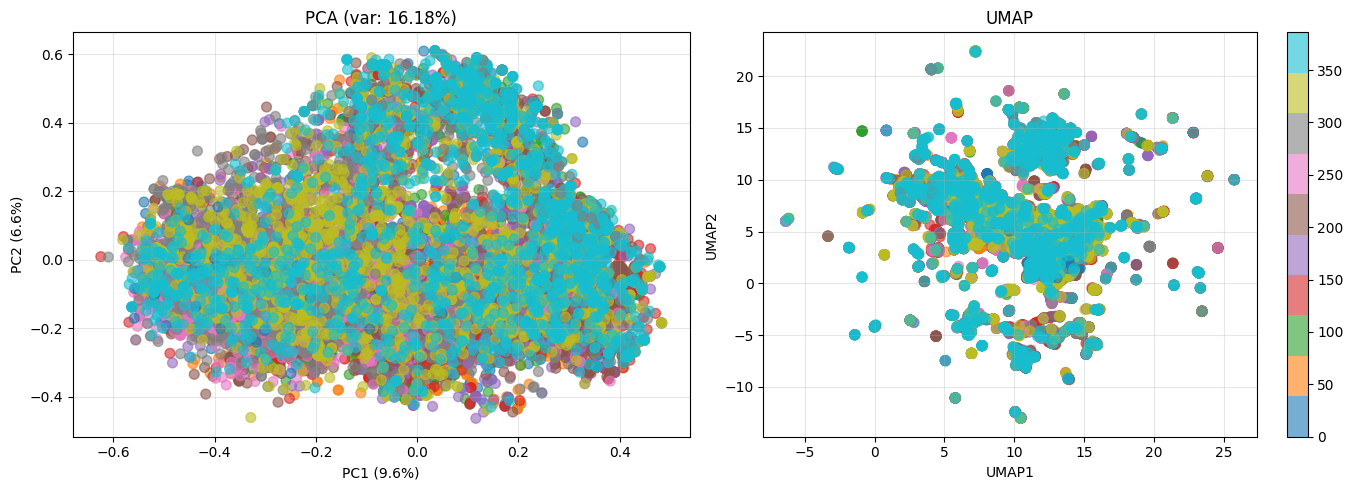

In [30]:
visualize_rag_embeddings(rag, data, group_by='Name')

In [ ]:
# Это кстати современное искусство, я шарю )

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

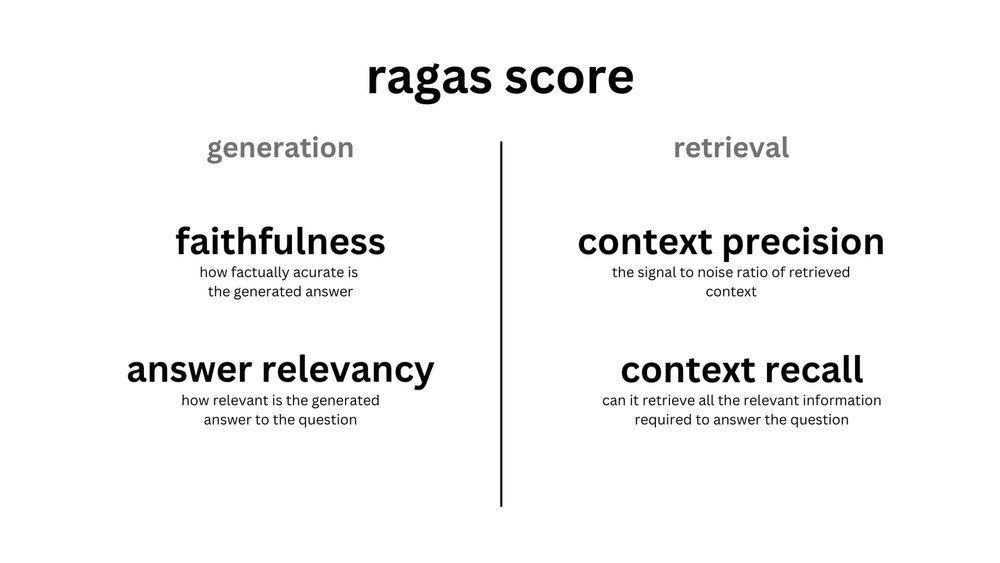

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
# Окей, сейчас будем заставлять модель придумать всякого... 

In [31]:
def generate_question(description: str, name: str, rag):
    rag._load_local_model()
    
    prompt = f"""Based on this description of {name}, generate one specific question that can be answered using this information. Generate only the question, nothing else.

Description: {description[:300]}

Question:"""
    
    messages = [{"role": "user", "content": prompt}]
    text = rag.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = rag.tokenizer([text], return_tensors="pt").to(rag.llm.device)
    
    outputs = rag.llm.generate(**inputs, max_new_tokens=50, temperature=0.7, do_sample=True)
    question = rag.tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True).strip()
    
    return question


def get_rag_answer(question: str, rag, name: str, top_k=3):
    results = rag.search(question, top_k=top_k, initial_k=20)
    contexts = []
    for r in results:
        all_texts = rag.data[rag.data['Name'] == r['Name']]['en_txt'].fillna('').tolist()
        contexts.extend(all_texts)

    combined = '\n\n'.join(contexts[:3])  
    
    rag._load_local_model()
    prompt = f"""Answer the following question based on the provided context. Be concise and specific.

Question: {question}

Context: {combined}

Answer:"""
    
    messages = [{"role": "user", "content": prompt}]
    text = rag.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = rag.tokenizer([text], return_tensors="pt").to(rag.llm.device)
    
    outputs = rag.llm.generate(**inputs, max_new_tokens=150, temperature=0.7, do_sample=True)
    answer = rag.tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True).strip()
    
    return answer, contexts[:3]


In [41]:
from tqdm import tqdm

def data_preprocess(data: pd.DataFrame, rag, n_samples=100, seed=42):
    sample_data = data.sample(n=min(n_samples, len(data)), random_state=seed).reset_index(drop=True)
    
    results = []
    
    for idx, row in tqdm(sample_data.iterrows(), total=len(sample_data), desc="Generating Q&A"):
        question = generate_question(row['en_txt'], row['Name'], rag)
        answer, contexts = get_rag_answer(question, rag, row['Name'])
        
        results.append({
            'question': question,
            'answer': answer,
            'contexts': contexts
        })
    
    return pd.DataFrame(results)

In [42]:
def answer_relevancy(questions: List[str], answers: List[str], 
                     model_name='all-MiniLM-L6-v2') -> Dict:

    embedder = SentenceTransformer(model_name)
    
    scores = []
    
    for question, answer in tqdm(zip(questions, answers), total=len(questions), desc="Computing relevancy"):
        question_emb = embedder.encode([question])
        answer_emb = embedder.encode([answer])
        similarity = cosine_similarity(question_emb, answer_emb)[0][0]
        scores.append(similarity)
    
    return {
        'answer_relevancy': float(np.mean(scores)),
        'scores': scores,
        'std': float(np.std(scores)),
        'min': float(np.min(scores)),
        'max': float(np.max(scores))
    }

# Протестируйте ваш RAG (3 балла)

In [ ]:
# Всё ещё пишет про повторяющиеся значения...
# Где они находятся я так и не понял...

In [ ]:
qa_data = data_preprocess(data, rag, n_samples=100)


metrics = answer_relevancy(
    questions=qa_data['question'].tolist(),
    answers=qa_data['answer'].tolist()
)



Generating Q&A:   0%|          | 0/100 [00:00<?, ?it/s]

WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


Generating Q&A:   1%|          | 1/100 [00:01<02:31,  1.53s/it]

WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


Generating Q&A:   2%|▏         | 2/100 [00:02<01:30,  1.08it/s]

...

WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


Generating Q&A:  99%|█████████▉| 99/100 [03:33<00:01,  1.89s/it]

WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


Computing relevancy: 100%|██████████| 100/100 [00:00<00:00, 101.94it/s]

Answer Relevancy: 0.7706
Std: 0.1020
Min: 0.4674, Max: 0.9454


In [ ]:
# В общем и целом выглядит неплохо 

In [45]:
print(f"Answer Relevancy: {metrics['answer_relevancy']:.4f}")
print(f"Std: {metrics['std']:.4f}")
print(f"Min: {metrics['min']:.4f}, Max: {metrics['max']:.4f}")

Answer Relevancy: 0.7706
Std: 0.1020
Min: 0.4674, Max: 0.9454


# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
# На да, тестим на синтетике.
# Посути заставляем проверять модель саму себя )

In [ ]:
import numpy as np
from typing import List, Dict
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm


def context_precision(questions: List[str], contexts: List[List[str]], 
                     ground_truths: List[str], threshold=0.5) -> Dict:

    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    precisions = []
    
    for question, ctx_list, gt in tqdm(zip(questions, contexts, ground_truths), 
                                       total=len(questions), desc="Context Precision"):
        gt_emb = embedder.encode([gt])
        ctx_embs = embedder.encode(ctx_list)
        
        similarities = cosine_similarity(gt_emb, ctx_embs)[0]
        relevant = similarities > threshold
        
        precision_at_k = []
        for k in range(1, len(ctx_list) + 1):
            relevant_in_topk = np.sum(relevant[:k])
            precision_at_k.append(relevant_in_topk / k)
        
        if np.sum(relevant) > 0:
            weighted_precision = np.sum([p * r for p, r in zip(precision_at_k, relevant)]) / np.sum(relevant)
        else:
            weighted_precision = 0.0
        
        precisions.append(weighted_precision)
    
    return {
        'context_precision': float(np.mean(precisions)),
        'scores': precisions,
        'std': float(np.std(precisions))
    }




def generate_ground_truths(questions: List[str], contexts: List[List[str]], rag) -> List[str]:
    rag._load_local_model()
    ground_truths = []
    
    for question, ctx_list in tqdm(zip(questions, contexts), 
                                   total=len(questions), desc="Generating ground truths"):
        combined_context = '\n\n'.join(ctx_list)
        
        prompt = f"""Based on the context, provide a comprehensive and accurate answer to the question. Include all relevant facts.

Question: {question}

Context: {combined_context}

Complete answer:"""
        
        messages = [{"role": "user", "content": prompt}]
        text = rag.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = rag.tokenizer([text], return_tensors="pt").to(rag.llm.device)
        
        outputs = rag.llm.generate(**inputs, max_new_tokens=200, temperature=0.3, do_sample=True)
        gt = rag.tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True).strip()
        
        ground_truths.append(gt)
    
    return ground_truths





In [ ]:

ground_truths = generate_ground_truths(
    questions=qa_data['question'].tolist(),
    contexts=qa_data['contexts'].tolist(),
    rag=rag
)


precision_metrics = context_precision(
    questions=qa_data['question'].tolist(),
    contexts=qa_data['contexts'].tolist(),
    ground_truths=ground_truths
)
print(f"Context Precision: {precision_metrics['context_precision']:.4f}")



Context Precision: 100%|██████████| 100/100 [00:01<00:00, 98.90it/s]

Context Precision: 0.4975
